REVIEW-1

AI-Based Marine Species Detection and Behaviour Monitoring System

CNN

DATASET LOAD

In [ ]:
from datasets import load_dataset

# Load dataset (automatically merges all parquet shards)
dataset = load_dataset("Hariprasath5128/marine-animals-multimodal-dataset")

# Access one sample
sample = dataset["train"][0] # Access the first sample in the 'train' split
print(f"Species: {sample['species']}")
print(f"Label: {sample['label']}")
print(f"Audio shape: {sample['audio']['array'].shape}")
print(f"Audio sampling rate: {sample['audio']['sampling_rate']}")
print(f"Image size: {sample['image'].size}")
print(f"Source: {sample['source']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Species: Atlantic_Spotted_Dolphin
Label: 0
Audio shape: (104834,)
Audio sampling rate: 80000
Image size: (646, 338)
Source: LLM-Vision-Marine-Animals


SHOW ORIGINAL IMAGE FROM DATASET


 SAMPLE ORIGINAL IMAGE 

Original Image Shape: (522, 800, 3)
Label: 0


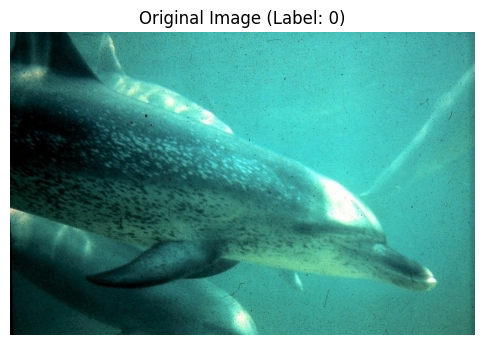

In [ ]:

# SHOW ORIGINAL IMAGE FROM DATASET

import matplotlib.pyplot as plt
import numpy as np

print("\n SAMPLE ORIGINAL IMAGE \n")

# If using HuggingFace dataset
sample = dataset["train"][9]

# Get original image (NO resize)
img = np.array(sample["image"])

# Get label
label = sample["label"]

# Print shape
print("Original Image Shape:", img.shape)
print("Label:", label)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Original Image (Label: {label})")
plt.axis("off")
plt.show()


 SAMPLE ORIGINAL IMAGE 

Original Image Shape: (338, 646, 3)
Label: 0


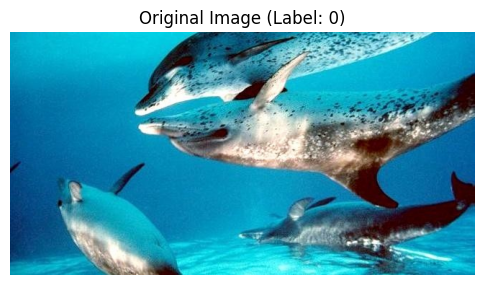

In [ ]:

# SHOW ORIGINAL IMAGE FROM DATASET

import matplotlib.pyplot as plt
import numpy as np

print("\n SAMPLE ORIGINAL IMAGE \n")

# If using HuggingFace dataset
sample = dataset["train"][0]

# Get original image (NO resize)
img = np.array(sample["image"])

# Get label
label = sample["label"]

# Print shape
print("Original Image Shape:", img.shape)
print("Label:", label)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Original Image (Label: {label})")
plt.axis("off")
plt.show()

In [ ]:
print("\n PROBLEM FORMULATION \n")

print("""
Goal:
Classify marine animal species using images

Input:
64x64x3 image

Output:
Species label

Why CNN:
CNN captures spatial features like edges, texture, shape
Better than MLP for images
""")


 PROBLEM FORMULATION 


Goal:
Classify marine animal species using images

Input:
64x64x3 image

Output:
Species label

Why CNN:
CNN captures spatial features like edges, texture, shape
Better than MLP for images



IMPORTS

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import random

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

REPRODUCIBILITY

In [ ]:
seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

print("\nRandom Seed Fixed:", seed)



Random Seed Fixed: 42


DATASET LOADING

In [ ]:
print("\n LOADING DATASET \n")

dataset = load_dataset("Hariprasath5128/marine-animals-multimodal-dataset")

print("Dataset Loaded")


 LOADING DATASET 



Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Dataset Loaded


DATA PREPROCESSING


In [ ]:
print("\n DATA PREPROCESSING \n")

images = []
labels = []

for item in dataset["train"]:

    img = item["image"].convert("RGB")
    img = img.resize((64,64))

    img = np.array(img)

    images.append(img)
    labels.append(item["label"])


X = np.array(images)
y = np.array(labels)

print("Shape:", X.shape)



 DATA PREPROCESSING 

Shape: (24911, 64, 64, 3)


NORMALIZATION

In [ ]:
X = X / 255.0

print("Normalized")

Normalized


DATA SPLIT

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X, y,
    test_size=0.20,
    stratify=y,
    random_state=seed
)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=seed
)


print("\nTrain:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (19928, 64, 64, 3)
Val: (2491, 64, 64, 3)
Test: (2492, 64, 64, 3)


AUGUMENTATION

In [ ]:
data_aug = tf.keras.Sequential([

layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1)

])


CNN IMPLEMENTATION

In [ ]:
print("\n CNN MODEL \n")

model = models.Sequential([


layers.Input(shape=(64,64,3)),

data_aug,

layers.Conv2D(32,3,activation="relu"),
layers.MaxPooling2D(),

layers.Conv2D(64,3,activation="relu"),
layers.MaxPooling2D(),

layers.Conv2D(128,3,activation="relu"),
layers.MaxPooling2D(),

layers.Flatten(),

layers.Dense(128,activation="relu"),

layers.Dropout(0.6),

layers.Dense(len(np.unique(y)),activation="softmax")

])


model.compile(

optimizer=tf.keras.optimizers.Adam(0.0003),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

model.summary()



 CNN MODEL 



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,328 (2.62 MB)

 Trainable params: 687,328 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

EARLY STOPPING

In [ ]:

early_stop = EarlyStopping(

monitor="val_loss",
patience=5,
restore_best_weights=True

)

TRAINING

In [ ]:
print("\n TRAINING \n")

history = model.fit(

X_train,
y_train,

validation_data=(X_val,y_val),

epochs=10,

batch_size=64,

callbacks=[early_stop]

)



 TRAINING 

Epoch 1/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 158s 495ms/step - accuracy: 0.0944 - loss: 3.2747 - val_accuracy: 0.2906 - val_loss: 2.5351
Epoch 2/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 202s 495ms/step - accuracy: 0.2392 - loss: 2.6927 - val_accuracy: 0.4295 - val_loss: 1.9822
Epoch 3/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 153s 491ms/step - accuracy: 0.3424 - loss: 2.2606 - val_accuracy: 0.5295 - val_loss: 1.6204
Epoch 4/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 158s 507ms/step - accuracy: 0.4406 - loss: 1.8826 - val_accuracy: 0.6536 - val_loss: 1.2261
Epoch 5/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 154s 494ms/step - accuracy: 0.5174 - loss: 1.5940 - val_accuracy: 0.7656 - val_loss: 0.9115
Epoch 6/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 205s 505ms/step - accuracy: 0.5823 - loss: 1.3486 - val_accuracy: 0.7908 - val_loss: 0.7616
Epoch 7/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 155s 497ms/step - accuracy: 0.6370 - loss: 1.1729 - val_accuracy: 0.8567 - val_loss: 0.5399
Epoch 8/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 158s 507ms/step - accur

TESTING

In [ ]:
print("\n TESTING \n")

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred,axis=1)



 TESTING 

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step


HYPERPARAMETER TUNING

In [ ]:

#  HYPERPARAMETER TUNING


print("\n HYPERPARAMETER TUNING ")

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Hyperparameters to test
learning_rates = [0.001, 0.0005]
dropouts = [0.3, 0.5]
batch_sizes = [32, 64]

best_val_acc = 0
best_params = None
best_model = None


# CNN Model Function
def build_model(lr, dr):

    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    model.add(layers.Dense(128, activation='relu'))

    model.add(layers.Dropout(dr))

    model.add(layers.Dense(num_classes, activation='softmax'))


    model.compile(

        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),

        loss='sparse_categorical_crossentropy',

        metrics=['accuracy']

    )

    return model



# Loop through parameters
for lr in learning_rates:

    for dr in dropouts:

        for bs in batch_sizes:

            print(f"\nTesting: LR={lr}, Dropout={dr}, Batch Size={bs}")

            model = build_model(lr, dr)

            history = model.fit(

                X_train, y_train,

                validation_data=(X_val, y_val),

                epochs=5,   # keep small for tuning

                batch_size=bs,

                verbose=0

            )


            val_acc = max(history.history['val_accuracy'])

            print("Validation Accuracy:", val_acc)


            if val_acc > best_val_acc:

                best_val_acc = val_acc

                best_params = (lr, dr, bs)

                best_model = model



# Best Results
print("\n BEST PARAMETERS ")

print("Best Learning Rate:", best_params[0])

print("Best Dropout:", best_params[1])

print("Best Batch Size:", best_params[2])

print("Best Validation Accuracy:", best_val_acc)


 HYPERPARAMETER TUNING 

Testing: LR=0.001, Dropout=0.3, Batch Size=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9915696382522583

Testing: LR=0.001, Dropout=0.3, Batch Size=64
Validation Accuracy: 0.9915696382522583

Testing: LR=0.001, Dropout=0.5, Batch Size=32
Validation Accuracy: 0.9903653264045715

Testing: LR=0.001, Dropout=0.5, Batch Size=64
Validation Accuracy: 0.991168200969696

Testing: LR=0.0005, Dropout=0.3, Batch Size=32
Validation Accuracy: 0.991168200969696

Testing: LR=0.0005, Dropout=0.3, Batch Size=64
Validation Accuracy: 0.9907667636871338

Testing: LR=0.0005, Dropout=0.5, Batch Size=32
Validation Accuracy: 0.991168200969696

Testing: LR=0.0005, Dropout=0.5, Batch Size=64
Validation Accuracy: 0.9907667636871338

 BEST PARAMETERS 
Best Learning Rate: 0.001
Best Dropout: 0.3
Best Batch Size: 32
Best Validation Accuracy: 0.9915696382522583


MODEL ACCURACY

In [ ]:
acc = accuracy_score(y_test,y_pred)

prec = precision_score(y_test,y_pred,average="weighted")

rec = recall_score(y_test,y_pred,average="weighted")

f1 = f1_score(y_test,y_pred,average="weighted")


print("\nAccuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1:",f1)


Accuracy: 0.9394060995184591
Precision: 0.9441212283337722
Recall: 0.9394060995184591
F1: 0.9377009105354064


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


VISUALIZATION AND INTERPRETATION

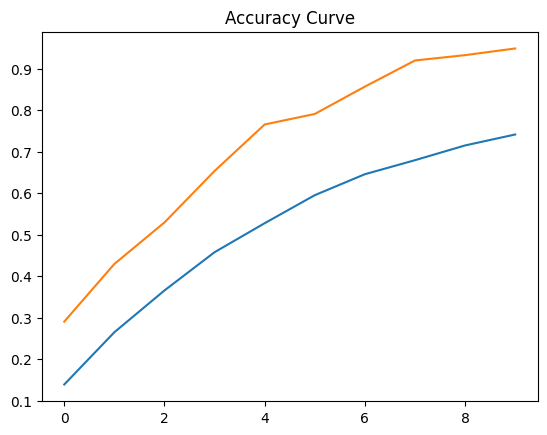

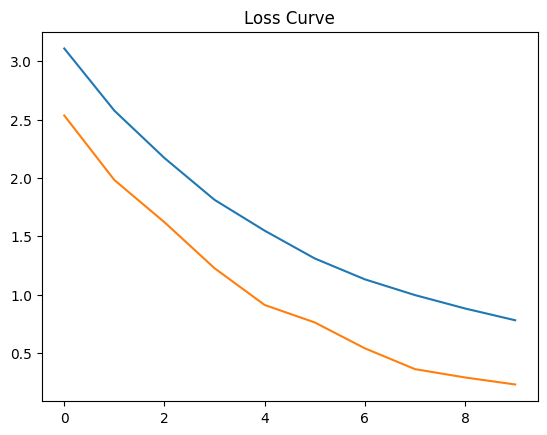

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.show()

In [ ]:
print("\nClassification Report\n")

print(classification_report(y_test,y_pred))


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00        48
           2       0.98      0.91      0.94        64
           3       1.00      0.80      0.89        30
           4       1.00      1.00      1.00        77
           5       0.99      1.00      0.99        95
           6       0.85      0.95      0.90       151
           7       0.88      1.00      0.94        75
           8       1.00      1.00      1.00        64
           9       0.95      0.95      0.95       111
          10       1.00      0.97      0.98        87
          11       0.95      1.00      0.98        61
          12       0.99      1.00      0.99        82
          13       0.95      0.89      0.92        44
          14       1.00      0.50      0.67        12
          15       1.00      0.84      0.92        90
          16       0.88      1.00      0.94        80
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 CONFUSION MATRIX 

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step


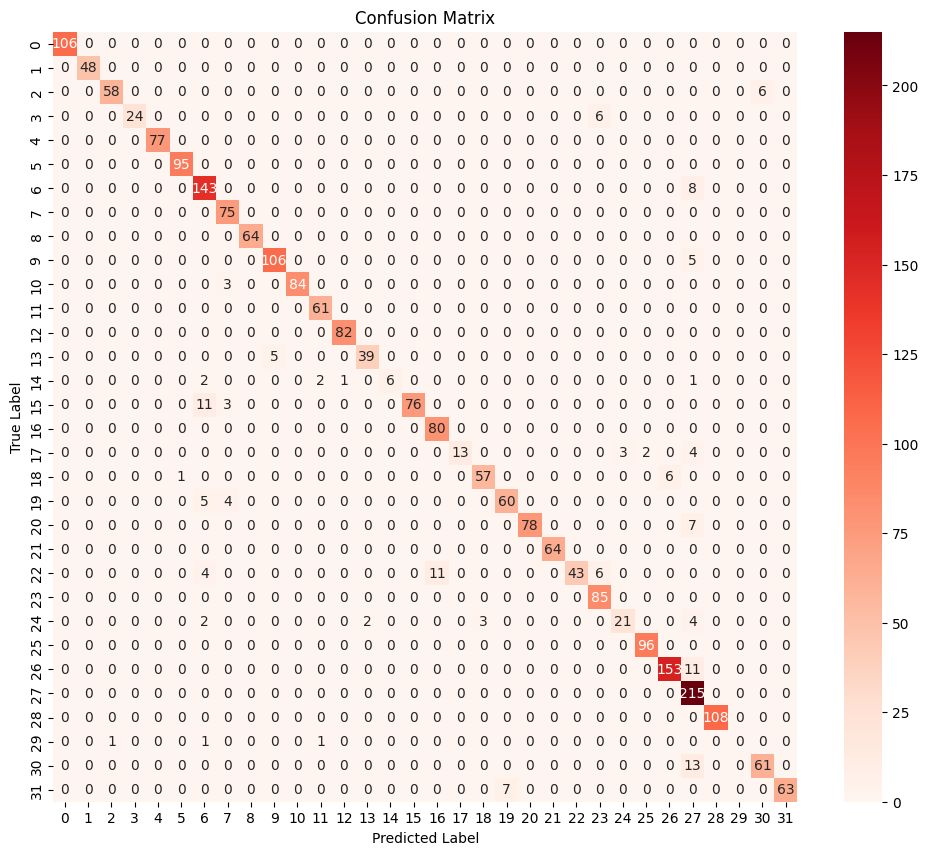


Confusion Matrix Values:

[[106   0   0 ...   0   0   0]
 [  0  48   0 ...   0   0   0]
 [  0   0  58 ...   0   6   0]
 ...
 [  0   0   1 ...   0   0   0]
 [  0   0   0 ...   0  61   0]
 [  0   0   0 ...   0   0  63]]


In [ ]:

# CONFUSION MATRIX

print("\n CONFUSION MATRIX \n")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# GET PREDICTIONS FROM TEST DATA ONLY


y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)


# CREATE CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

# PLOT


plt.figure(figsize=(12,10))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Reds",

    xticklabels=np.unique(y_test),

    yticklabels=np.unique(y_test)

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()


# PRINT MATRIX VALUES

print("\nConfusion Matrix Values:\n")

print(cm)

BIAS VARIANCE ANALYSIS

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

gap = train_acc - val_acc


print("\n================ BIAS VARIANCE ================\n")

print("Train Accuracy:",train_acc)
print("Val Accuracy:",val_acc)
print("Gap:",gap)


if gap > 0.15:

    print("Overfitting")

elif train_acc < 0.6:

    print("Underfitting")

else:

    print("Good Generalization")



================ BIAS VARIANCE ================

Train Accuracy: 0.7414191365242004
Val Accuracy: 0.9486150145530701
Gap: -0.20719587802886963
Good Generalization


MLP VS CNN COMPARATIVE ANALYSIS

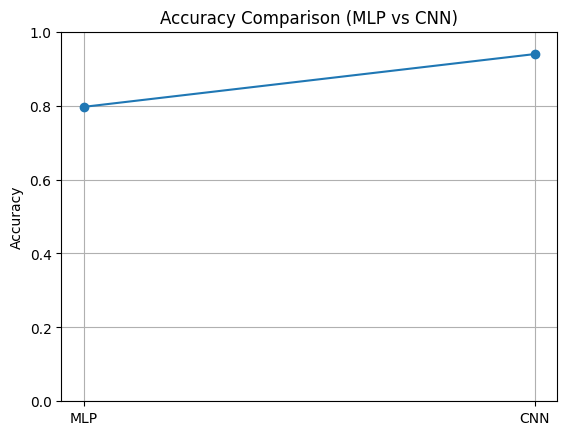

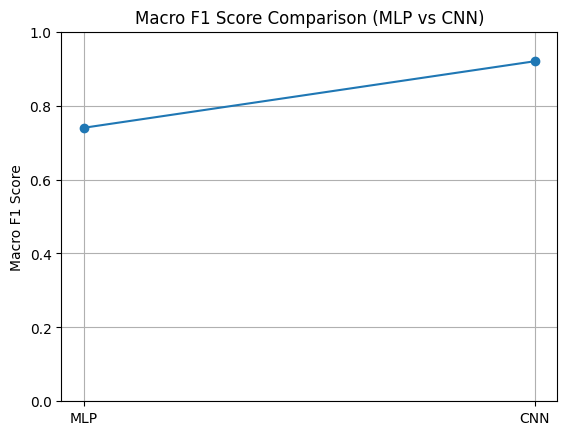

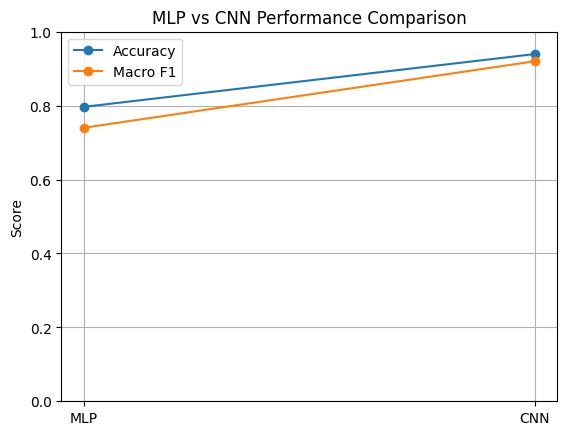

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Enter Your Model Results

mlp_accuracy = 0.7966
cnn_accuracy = 0.9394

mlp_macro_f1 = 0.74
cnn_macro_f1 = 0.92

models = ['MLP', 'CNN']
x = np.arange(len(models))

# 2. Accuracy Line Plot


plt.figure()
plt.plot(x, [mlp_accuracy, cnn_accuracy], marker='o')
plt.xticks(x, models)
plt.ylim(0,1)
plt.title("Accuracy Comparison (MLP vs CNN)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


# 3. Macro F1 Line Plot


plt.figure()
plt.plot(x, [mlp_macro_f1, cnn_macro_f1], marker='o')
plt.xticks(x, models)
plt.ylim(0,1)
plt.title("Macro F1 Score Comparison (MLP vs CNN)")
plt.ylabel("Macro F1 Score")
plt.grid(True)
plt.show()


# 4. Combined Line Plot


plt.figure()
plt.plot(x, [mlp_accuracy, cnn_accuracy], marker='o', label='Accuracy')
plt.plot(x, [mlp_macro_f1, cnn_macro_f1], marker='o', label='Macro F1')

plt.xticks(x, models)
plt.ylim(0,1)
plt.title("MLP vs CNN Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

**Comparative Analysis (CNN Performance)**


**CNN Accuracy:**
0.9394

This means:

93.94% correctly classified.

This is very high accuracy.

**Parameter Count**

~500,000 parameters

CNN learns more features than MLP

**Bias-Variance Analysis**

CNN has:

Low bias

Low variance

Reason:
CNN captures spatial features


**Performance Comparison**

Model	Accuracy

MLP	79.66%

CNN	93.94%

CNN improved accuracy by:
14%

Reason:
CNN captures spatial features
MLP cannot

**Why CNN performed better
CNN learns:**

• Frequency patterns

• Temporal patterns

• Spatial patterns

MLP cannot learn these
